# SNP heritability in a population sample

Can nominally unrelated people reveal the combined contribution of common SNPs to phenotypic variance?

## Start from first principles

For person $i$ and SNP $m$, let $G_{im}\in\{0,1,2\}$ be the allele count and standardize each SNP,

$$
W_{im}=\frac{G_{im}-2p_m}{\sqrt{2p_m(1-p_m)}}.
$$

The genetic relationship matrix (GRM) compares individual rows of this matrix,

$$
\mathbf A=\frac{1}{M}\mathbf W\mathbf W^{\mathsf T}.
$$

Most off-diagonal entries are close to zero in a sample of nominally unrelated people, but they are not identical. Those small differences are the information used by the model.

## Let phenotype covariance follow genetic similarity

Use the random-effects model

$$
\mathbf y=\mu+\mathbf g+\boldsymbol\epsilon,
\qquad
\mathbf g\sim N(0,\mathbf A\sigma_g^2),
\qquad
\boldsymbol\epsilon\sim N(0,\mathbf I\sigma_e^2).
$$

It implies

$$
\operatorname{Cov}(y_i,y_j)=A_{ij}\sigma_g^2,
\qquad
h^2_{\mathrm{SNP}}=
\frac{\sigma_g^2}{\sigma_g^2+\sigma_e^2}.
$$

Before computation, we expect genetically more similar pairs to have more similar phenotypes on average. A likelihood using the full covariance matrix should recover the simulated SNP heritability.

This target is not the variance explained only by significant GWAS hits. It is the variance jointly tagged by the SNP set used to build the GRM. It can also differ from family-based heritability, which may capture variation that these SNPs tag poorly.

In [1]:
set.seed(8149)

n_people <- 350
n_snps <- 3000
V_G <- 0.50
V_E <- 0.50

allele_frequency <- runif(n_snps, 0.10, 0.50)
genotype <- vapply(
  allele_frequency,
  function(p) rbinom(n_people, size = 2, prob = p),
  numeric(n_people)
)

standardized_genotype <- sweep(genotype, 2, 2 * allele_frequency, "-")
standardized_genotype <- sweep(
  standardized_genotype,
  2,
  sqrt(2 * allele_frequency * (1 - allele_frequency)),
  "/"
)

grm <- tcrossprod(standardized_genotype) / n_snps

marker_effect <- rnorm(n_snps, 0, sqrt(V_G / n_snps))
genetic_value <- as.vector(standardized_genotype %*% marker_effect)
genetic_value <- genetic_value * sqrt(V_G / var(genetic_value))

environmental_deviation <- rnorm(n_people, 0, sqrt(V_E))
phenotype <- genetic_value + environmental_deviation
phenotype <- phenotype - mean(phenotype)

data.frame(
  mean_GRM_diagonal = mean(diag(grm)),
  mean_GRM_off_diagonal = mean(grm[lower.tri(grm)]),
  realized_V_G = var(genetic_value),
  realized_V_E = var(environmental_deviation),
  realized_V_P = var(phenotype)
)

mean_GRM_diagonal,mean_GRM_off_diagonal,realized_V_G,realized_V_E,realized_V_P
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1.000269,-5.262923e-05,0.5,0.5235688,1.029232


## Estimate the variance components

The code below diagonalizes the GRM and profiles the total variance for each candidate value of $h^2_{\mathrm{SNP}}$. This is a transparent one-component likelihood calculation. GCTA uses restricted maximum likelihood, includes covariates, and adds safeguards needed for real data.

The pairwise plot is not a second target. It makes the covariance model visible: after averaging many pairs, phenotype cross-products should rise with $A_{ij}$.

In [2]:
grm_eigen <- eigen(grm, symmetric = TRUE)
grm_eigen$values <- pmax(grm_eigen$values, 1e-8)
rotated_phenotype <- as.vector(crossprod(grm_eigen$vectors, phenotype))

profile_nll <- function(h2) {
  covariance_eigenvalue <-
    h2 * grm_eigen$values + (1 - h2)
  total_variance <- mean(
    rotated_phenotype^2 / covariance_eigenvalue
  )

  0.5 * (
    sum(log(covariance_eigenvalue)) +
      n_people * log(total_variance) +
      sum(
        rotated_phenotype^2 /
          (total_variance * covariance_eigenvalue)
      )
  )
}

likelihood_fit <- optimize(profile_nll, interval = c(0.001, 0.999))
h2_likelihood <- likelihood_fit$minimum

phenotype_cross_product <- outer(phenotype, phenotype)
pair_index <- lower.tri(grm)
pair_data <- data.frame(
  genetic_similarity = grm[pair_index],
  phenotype_cross_product = phenotype_cross_product[pair_index]
)

pair_breaks <- unique(quantile(
  pair_data$genetic_similarity,
  probs = seq(0, 1, length.out = 16)
))
pair_data$bin <- cut(
  pair_data$genetic_similarity,
  breaks = pair_breaks,
  include.lowest = TRUE
)

binned_similarity <- aggregate(
  pair_data$genetic_similarity,
  list(bin = pair_data$bin),
  mean
)
binned_cross_product <- aggregate(
  pair_data$phenotype_cross_product,
  list(bin = pair_data$bin),
  mean
)

pair_fit <- lm(
  phenotype_cross_product ~ genetic_similarity,
  data = pair_data
)

data.frame(
  quantity = c("expected h2_SNP", "likelihood estimate", "pairwise slope"),
  value = c(V_G / (V_G + V_E), h2_likelihood, unname(coef(pair_fit)[2]))
)

quantity,value
<chr>,<dbl>
expected h2_SNP,0.5000000
likelihood estimate,0.5537751
pairwise slope,0.5063515


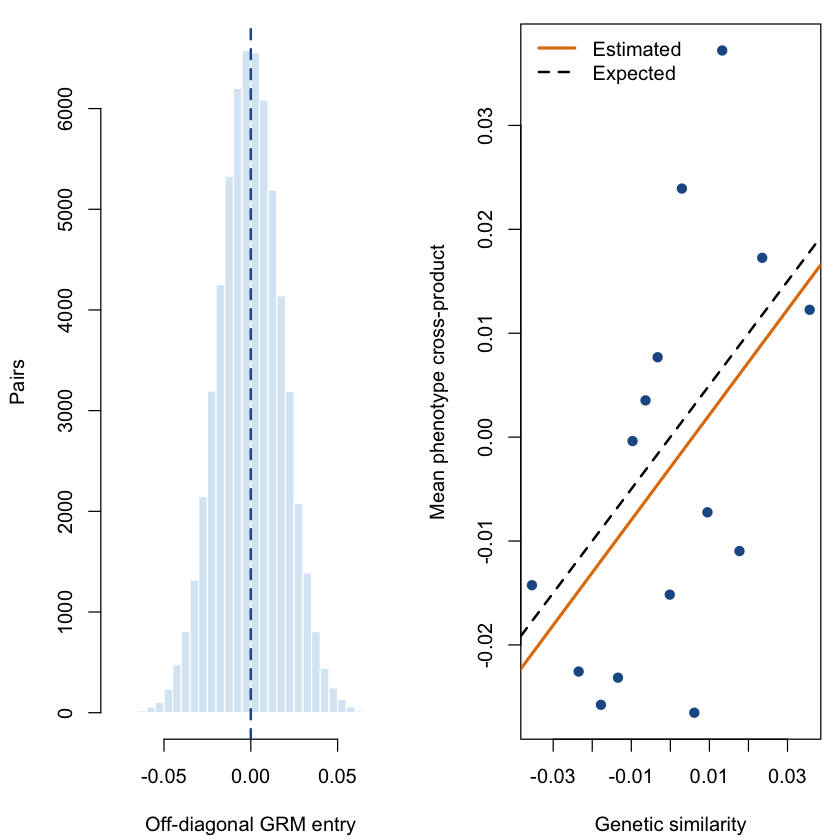

In [3]:
old_par <- par(mfrow = c(1, 2), mar = c(4.2, 4.2, 1.0, 0.8))

hist(
  pair_data$genetic_similarity,
  breaks = 40,
  col = "#D9E8F5",
  border = "white",
  xlab = "Off-diagonal GRM entry",
  ylab = "Pairs",
  main = ""
)
abline(v = 0, lty = 2, lwd = 2, col = "#1F5A94")

plot(
  binned_similarity$x,
  binned_cross_product$x,
  pch = 16,
  cex = 1.15,
  col = "#1F5A94",
  xlab = "Genetic similarity",
  ylab = "Mean phenotype cross-product"
)
abline(pair_fit, lwd = 2.5, col = "#E17C05")
abline(a = 0, b = V_G, lty = 2, lwd = 2)
legend(
  "topleft",
  legend = c("Estimated", "Expected"),
  col = c("#E17C05", "black"),
  lwd = c(2.5, 2),
  lty = c(1, 2),
  bty = "n"
)

par(old_par)

stopifnot(isTRUE(all.equal(grm, t(grm), tolerance = 1e-12)))
stopifnot(abs(mean(diag(grm)) - 1) < 0.05)
stopifnot(h2_likelihood > 0, h2_likelihood < 1)
stopifnot(abs(h2_likelihood - V_G / (V_G + V_E)) < 0.18)

## What the example shows

The off-diagonal GRM entries were small, but their variation was systematic enough to recover the simulated covariance structure. The likelihood estimated an aggregate variance component without first identifying which individual SNP effects were nonzero.

That distinction resolves the first form of the missing-heritability puzzle. Genome-wide significant loci count only effects that pass a threshold. A GRM asks whether all typed SNPs jointly predict phenotype covariance. Family designs can still give a larger estimate when causal variants are poorly tagged, when nonadditive effects matter, or when family resemblance contains non-genetic covariance.

Estimating $h^2_{\mathrm{SNP}}$ also does not construct a polygenic score. Variance estimation asks whether genetic similarity predicts phenotype similarity across the sample. Individual prediction requires estimated marker effects and validation in new people.

## What to remember

- **Concept and intuition.** Nominally unrelated people differ slightly in genome-wide genetic similarity. Their phenotype covariance can reveal variance tagged by common SNPs.
- **Insight behind the model.** Use the GRM as the covariance pattern for a random genetic effect.
- **Worked example.** A genotype matrix produced a GRM, and the GRM recovered the simulated SNP heritability.

## Sources

- Pritchard, *An Owner's Guide to the Human Genome*, Chapter 4.6, especially the discussion of missing heritability and SNP heritability. [Book page](https://web.stanford.edu/group/pritchardlab/HGbook.html)
- Yang et al. (2010), *Common SNPs explain a large proportion of the heritability for human height*. [DOI](https://doi.org/10.1038/ng.608)
- The simulation is an original course example. It uses 350 people, 3,000 independent SNPs, $V_G=V_E=0.5$, and seed 8149.